Zadanie 1


In [ ]:
import numpy as np
import time
import cupy as cp
import locale

# N = 1024
# A_cpu = np.random.rand(N, N).astype(np.float32)
# B_cpu = np.random.rand(N, N).astype(np.float32)
# start = time.time()
# C_cpu = np.matmul(A_cpu, B_cpu)
# end = time.time()
# print(f"Mnożenie macierzy na CPU trwało: {end - start:.5f} sekund.")
# A_gpu = cp.array(A_cpu)
# B_gpu = cp.array(B_cpu)
# start = time.time()
# C_gpu = cp.matmul(A_gpu, B_gpu)
# cp.cuda.Stream.null.synchronize()
# end = time.time()
# del C_gpu, A_gpu, B_gpu
# print(f"Mnożenie macierzy na GPU trwało: {end - start:.5f} sekund.")


Kernel (zadanie 2):

In [ ]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"
!pip install pycuda

In [ ]:
kernel_code = """
__global__ void matrixMul ( float *A, float *B, float *C, int N) {
 int row = blockIdx.y * blockDim.y + threadIdx.y;
 int col = blockIdx.x * blockDim.x + threadIdx.x;
 float sum = 0.0;
 if(row < N && col < N) {
 for (int k = 0; k < N; k++) {
 sum += A[ row * N + k] * B[k * N + col ];
 }
 C[ row * N + col] = sum;
 }
}
"""


In [ ]:
import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule

# mod = SourceModule(kernel_code)
# matrixMul = mod.get_function("matrixMul")

# C_cpu = np.empty((N, N), np.float32)
# A_gpu = cuda.mem_alloc(A_cpu.nbytes)
# B_gpu = cuda.mem_alloc(B_cpu.nbytes)
# C_gpu = cuda.mem_alloc(C_cpu.nbytes)

# cuda.memcpy_htod(A_gpu, A_cpu)
# cuda.memcpy_htod(B_gpu, B_cpu)

# block_size = (32, 32, 1)
# grid_size = (int(N/32), int(N/32), 1)
# matrixMul(A_gpu, B_gpu, C_gpu, np.int32(N), block=block_size, grid=grid_size)

# cuda.Context.synchronize()
# cuda.memcpy_dtoh(C_cpu, C_gpu)

# del A_gpu, B_gpu, C_gpu

Zadanie 3 (pomiary)



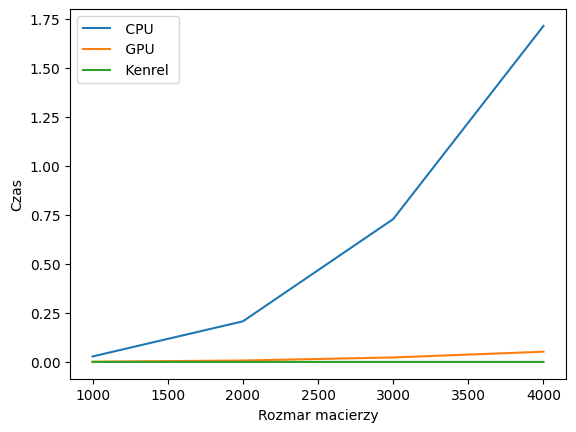

In [ ]:
import matplotlib.pyplot as plt

def multiply_cpu_get_time(N: int):
  A_cpu = np.random.rand(N, N).astype(np.float32)
  B_cpu = np.random.rand(N, N).astype(np.float32)
  start = time.time()
  C_cpu = np.matmul(A_cpu, B_cpu)
  end = time.time()
  return end - start

def multiply_gpu_get_time(N: int):
  A_cpu = np.random.rand(N, N).astype(np.float32)
  B_cpu = np.random.rand(N, N).astype(np.float32)
  A_gpu = cp.array(A_cpu)
  B_gpu = cp.array(B_cpu)

  start = time.time()
  C_gpu = cp.matmul(A_gpu, B_gpu)
  cp.cuda.Stream.null.synchronize()
  end = time.time()

  del A_gpu, B_gpu, C_gpu
  return end - start

def multiply_kernel_get_time(N: int):


  mod = SourceModule(kernel_code)
  matrixMul = mod.get_function("matrixMul")
  A_cpu = np.random.rand(N, N).astype(np.float32)
  B_cpu = np.random.rand(N, N).astype(np.float32)
  C_cpu = np.empty((N, N), np.float32)

  A_gpu = cuda.mem_alloc(A_cpu.nbytes)
  B_gpu = cuda.mem_alloc(B_cpu.nbytes)
  C_gpu = cuda.mem_alloc(C_cpu.nbytes)

  cuda.memcpy_htod(A_gpu, A_cpu)
  cuda.memcpy_htod(B_gpu, B_cpu)

  block_size = (32, 32, 1)
  grid_size = (int(N/32), int(N/32), 1)

  start = time.time()
  matrixMul(A_gpu, B_gpu, C_gpu, np.int32(N), block=block_size, grid=grid_size)
  end = time.time()

  cuda.Context.synchronize()
  cuda.memcpy_dtoh(C_cpu, C_gpu)

  del A_gpu, B_gpu, C_gpu
  return end-start

x = [i for i in range(1000, 5000, 1000)]
cpu_measurements = np.zeros(4)
gpu_measurements = np.zeros(4)
kernel_measurements = np.zeros(4)

for i in range (0,4):
  cpu_measurements[i] = multiply_cpu_get_time(1000 * (i+1))
  gpu_measurements[i] = multiply_gpu_get_time(1000 * (i+1))
  kernel_measurements[i] = multiply_kernel_get_time(1000 * (i+1))

plt.plot (x, cpu_measurements, label =" CPU ")
plt.plot (x, gpu_measurements, label =" GPU ")
plt.plot (x, kernel_measurements, label =" Kenrel ")
plt.legend ()
plt.xlabel ("Rozmar macierzy")
plt.ylabel ("Czas")
plt.show ()
